# Terminal payoff density — conditioned on survival

Visualises the distribution of $\Pi_T = (w_1 S^1_T - w_2 S^2_T)^+ \mathbf{1}_{\{\tau > T\}}$ given $\tau > T$.

**Structural fact (Appendix A):** On $\{\tau > T\}$, $Z_T > -h_0$ implies $e^{h_0+Z_T} > 1 > b$, so
$Y := \Pi_T \mid \tau > T$ is **always strictly positive**. However, because $e^{X_{2,T}}$ can be
arbitrarily close to zero, $\inf Y = 0$, and the support is $(0,\infty)$ with no mass at zero and
no positive location shift.

**Parametric approximation (Appendix A):** We fit a **GB2** $(a, \beta, p, q)$ distribution
to the four conditional moments $\mu_k^+ = M_k / p_{\mathrm{surv}}$, $k=1,\ldots,4$.
The GB2 density is
$$
f_Y(y) = \frac{a\, y^{ap-1}}{\beta^{ap}\, B(p,q)\,(1+(y/\beta)^a)^{p+q}}, \quad y > 0,
$$
with moments $\mathbb{E}[Y^k] = \beta^k B(p+k/a,\, q-k/a) / B(p,q)$ for $k < aq$.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

from optimal_long_short.model_params import KouParams
from optimal_long_short.market_params import MarketParams
from optimal_long_short.strategy import UnitExposureLongShortStrategy
from optimal_long_short.inversion import TalbotInverter
from optimal_long_short.moments import ConditionalMoments
from optimal_long_short.monte_carlo import MonteCarlo
from optimal_long_short.pdf_approximation import GB2Approximation, gb2_pdf, gb2_cdf

In [2]:
# ── Model parameters (same as compare_laplace_vs_mc) ──────────────────────────
params = KouParams(
    mu1=0.05, sigma1=0.20, lam1=1.0, p1=0.5, eta1_pos=0.10, eta1_neg=0.125,
    mu2=0.03, sigma2=0.15, lam2=0.8, p2=0.5, eta2_pos=1/12, eta2_neg=1/9,
    rho=0.95,
)
market = MarketParams(b=0.8, S10=1.0, S20=1.0)
T = 1.0
h0 = 0.5

N_PATHS = 200_000
N_STEPS = 252
SEED = 42

strategy = UnitExposureLongShortStrategy(h0=h0, market=market, T=T)
print(f"h0={h0},  b={market.b},  T={T}")
print(f"w1={strategy.w1:.4f},  w2={strategy.w2:.4f},  H0=exp(h0)={strategy.H:.4f}")

h0=0.5,  b=0.8,  T=1.0
w1=1.9426,  w2=0.9426,  H0=exp(h0)=1.6487


In [3]:
# ── Monte Carlo ───────────────────────────────────────────────────────────────
mc = MonteCarlo(params=params, strategy=strategy, n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED)
result = mc.run()

payoff_given_surv = result.payoff[result.survived]   # always > 0
print(f"n_survived = {result.survived.sum():,} / {N_PATHS:,}  (p_surv = {result.p_surv:.5f})")
print(f"min payoff = {payoff_given_surv.min():.2e}  (should be > 0)")

n_survived = 195,017 / 200,000  (p_surv = 0.97508)
min payoff = 1.45e-01  (should be > 0)


In [4]:
# ── Fit GB2 via Laplace moments ───────────────────────────────────────────────
gb2_approx = GB2Approximation(
    params=params,
    strategy=strategy,
    inverter=TalbotInverter(M=36),
).fit()

print(gb2_approx.summary())
print()
print(f"p_surv  MC = {result.p_surv:.6f}")

GB2 fit   a=3.4144  beta=1.158429  p=1.3954  q=1.9210
Existence q > 4/a:  1.9210 > 1.1715  -> True
p_surv = 0.973830

   k        target           GB2     rel_err
  ----------------------------------------
   1      1.095075      1.095075    0.00e+00
   2      1.381943      1.381943    2.60e-14
   3      2.029152      2.029152    3.24e-14
   4      3.580598      3.580598    1.28e-13

p_surv  MC = 0.975085


## Density plots

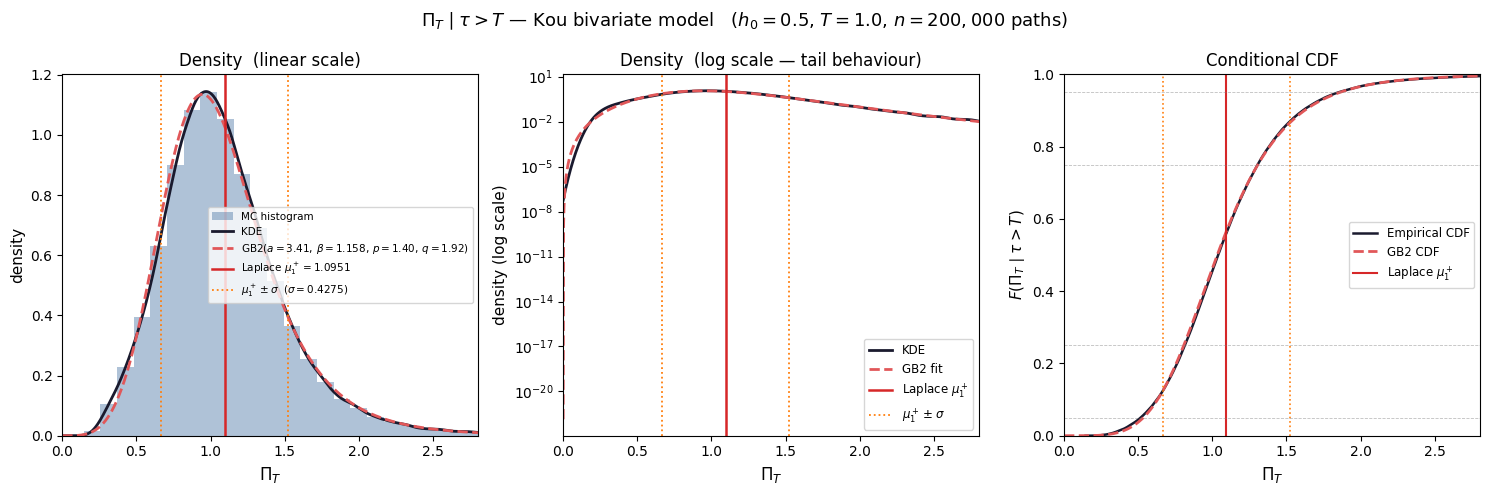

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    rf"$\Pi_T \mid \tau > T$ — Kou bivariate model   "
    rf"($h_0={h0}$, $T={T}$, $n={{{N_PATHS:,}}}$ paths)",
    fontsize=13,
)

c_hist = "#4e79a7"
c_kde  = "#1a1a2e"
c_gb2  = "#e15759"
c_mean = "#d62728"
c_std  = "#ff7f0e"

a_fit, beta_fit = gb2_approx.a, gb2_approx.beta
p_fit, q_fit    = gb2_approx.p, gb2_approx.q
lap_mean = gb2_approx.mu_plus[0]
lap_std  = np.sqrt(gb2_approx.mu_plus[1] - gb2_approx.mu_plus[0]**2)

x_max  = np.quantile(payoff_given_surv, 0.995)
x_grid = np.linspace(1e-6, x_max, 1000)

kde_fit      = gaussian_kde(payoff_given_surv, bw_method="scott")
gb2_pdf_vals = gb2_pdf(x_grid, a_fit, beta_fit, p_fit, q_fit)

# ─── panel 1: linear density ──────────────────────────────────────────────────
ax = axes[0]
ax.hist(payoff_given_surv, bins=80, density=True,
        color=c_hist, alpha=0.45, label="MC histogram")
ax.plot(x_grid, kde_fit(x_grid), color=c_kde, lw=2, label="KDE")
ax.plot(x_grid, gb2_pdf_vals, color=c_gb2, lw=2, ls="--",
        label=rf"GB2$(a={a_fit:.2f},\,\beta={beta_fit:.3f},\,p={p_fit:.2f},\,q={q_fit:.2f})$")
ax.axvline(lap_mean, color=c_mean, lw=1.8,
           label=rf"Laplace $\mu_1^+ = {lap_mean:.4f}$")
ax.axvline(lap_mean - lap_std, color=c_std, lw=1.3, ls=":")
ax.axvline(lap_mean + lap_std, color=c_std, lw=1.3, ls=":",
           label=rf"$\mu_1^+ \pm \sigma$  ($\sigma={lap_std:.4f}$)")
ax.set_xlabel(r"$\Pi_T$", fontsize=12)
ax.set_ylabel("density", fontsize=11)
ax.set_title("Density  (linear scale)")
ax.set_xlim(0, x_max)
ax.legend(fontsize=7.5)

# ─── panel 2: log-scale density ───────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x_grid, kde_fit(x_grid), color=c_kde, lw=2, label="KDE")
ax2.plot(x_grid, gb2_pdf_vals, color=c_gb2, lw=2, ls="--", label="GB2 fit")
ax2.axvline(lap_mean, color=c_mean, lw=1.8, label=r"Laplace $\mu_1^+$")
ax2.axvline(lap_mean - lap_std, color=c_std, lw=1.3, ls=":")
ax2.axvline(lap_mean + lap_std, color=c_std, lw=1.3, ls=":",
            label=r"$\mu_1^+ \pm \sigma$")
ax2.set_yscale("log")
ax2.set_xlabel(r"$\Pi_T$", fontsize=12)
ax2.set_ylabel("density (log scale)", fontsize=11)
ax2.set_title("Density  (log scale — tail behaviour)")
ax2.set_xlim(0, x_max)
ax2.legend(fontsize=8.5)

# ─── panel 3: CDF ─────────────────────────────────────────────────────────────
ax3 = axes[2]
sorted_pay = np.sort(payoff_given_surv)
ecdf = np.arange(1, len(sorted_pay) + 1) / len(sorted_pay)
ax3.plot(sorted_pay, ecdf, color=c_kde, lw=1.8, label="Empirical CDF")
ax3.plot(x_grid, gb2_approx.cdf(x_grid), color=c_gb2, lw=2, ls="--", label="GB2 CDF")
ax3.axvline(lap_mean, color=c_mean, lw=1.5, label=r"Laplace $\mu_1^+$")
ax3.axvline(lap_mean - lap_std, color=c_std, lw=1.2, ls=":")
ax3.axvline(lap_mean + lap_std, color=c_std, lw=1.2, ls=":")
for level in [0.05, 0.25, 0.75, 0.95]:
    ax3.axhline(level, color="grey", lw=0.6, ls="--", alpha=0.5)
ax3.set_xlabel(r"$\Pi_T$", fontsize=12)
ax3.set_ylabel(r"$F(\Pi_T \mid \tau > T)$", fontsize=11)
ax3.set_title("Conditional CDF")
ax3.set_xlim(0, x_max)
ax3.set_ylim(0, 1)
ax3.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

## Effect of the barrier distance $h_0$

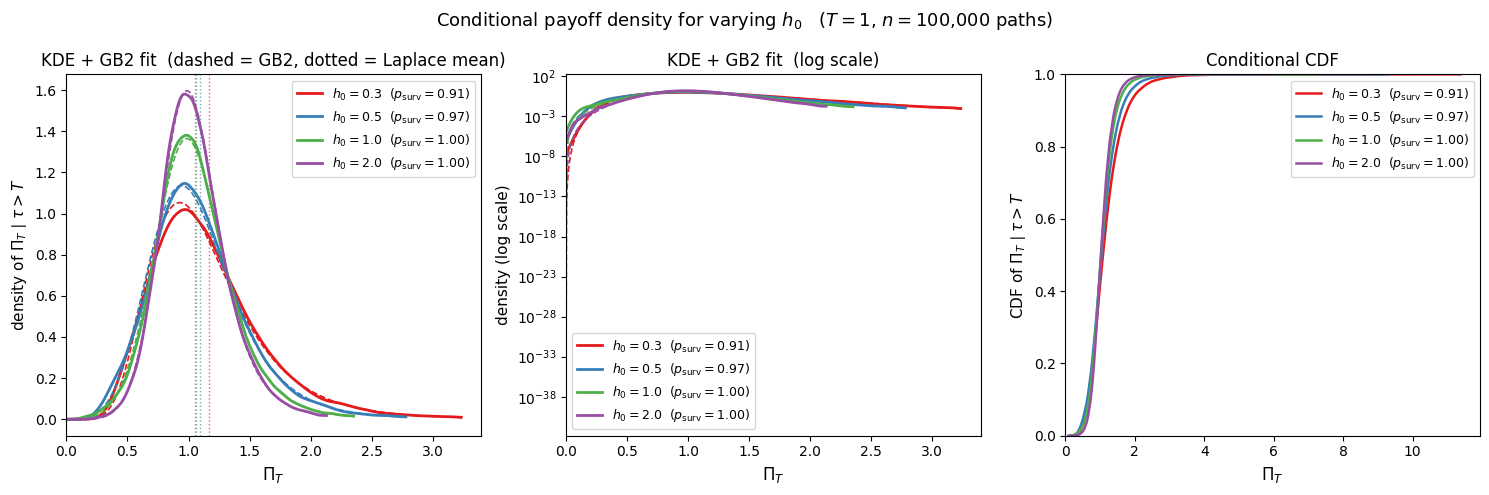

   h0 |  p_surv MC  p_surv Lap |   mean MC  mean Lap |   std MC  std Lap
------------------------------------------------------------------------
 0.30 |    0.90507     0.90394 |   1.16855   1.16846 |  0.49958  0.50036
 0.50 |    0.97372     0.97383 |   1.09587   1.09507 |  0.42692  0.42750
 1.00 |    0.99905     0.99905 |   1.06168   1.06089 |  0.34351  0.34376
 2.00 |    1.00000     1.00000 |   1.05464   1.05380 |  0.29208  0.29223


In [6]:
h0_values = [0.3, 0.5, 1.0, 2.0]
palette   = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    r"Conditional payoff density for varying $h_0$   ($T=1$, $n=100{,}000$ paths)",
    fontsize=13,
)

summary = []

for h0_val, color in zip(h0_values, palette):
    strat_i = UnitExposureLongShortStrategy(h0=h0_val, market=market, T=T)
    mc_i    = MonteCarlo(params=params, strategy=strat_i,
                         n_paths=100_000, n_steps=N_STEPS, seed=SEED)
    res_i   = mc_i.run()
    pay_i   = res_i.payoff[res_i.survived]
    if len(pay_i) < 200:
        continue

    approx_i = GB2Approximation(
        params=params,
        strategy=strat_i,
        inverter=TalbotInverter(M=32),
    ).fit()

    summary.append(dict(
        h0=h0_val,
        p_surv=res_i.p_surv,
        lap_p_surv=approx_i.p_surv,
        mc_mean=res_i.conditional_mean,
        lap_mean=approx_i.mu_plus[0],
        mc_std=np.sqrt(res_i.conditional_variance),
        lap_std=np.sqrt(approx_i.mu_plus[1] - approx_i.mu_plus[0]**2),
    ))

    x_max_i = np.quantile(pay_i, 0.995)
    xg_i    = np.linspace(1e-6, x_max_i, 600)
    kde_i   = gaussian_kde(pay_i, bw_method="scott")
    label   = rf"$h_0={h0_val}$  ($p_\mathrm{{surv}}={res_i.p_surv:.2f}$)"

    axes[0].plot(xg_i, kde_i(xg_i), color=color, lw=2, label=label)
    axes[0].plot(xg_i, approx_i.pdf(xg_i), color=color, lw=1.2, ls="--")
    axes[0].axvline(approx_i.mu_plus[0], color=color, lw=1.0, ls=":", alpha=0.7)

    axes[1].plot(xg_i, kde_i(xg_i), color=color, lw=2, label=label)
    axes[1].plot(xg_i, approx_i.pdf(xg_i), color=color, lw=1.2, ls="--")

    sorted_i = np.sort(pay_i)
    cdf_i    = np.arange(1, len(sorted_i) + 1) / len(sorted_i)
    axes[2].plot(sorted_i, cdf_i, color=color, lw=1.8, label=label)

axes[0].set_xlabel(r"$\Pi_T$", fontsize=12)
axes[0].set_ylabel(r"density of $\Pi_T\mid\tau>T$", fontsize=11)
axes[0].set_title("KDE + GB2 fit  (dashed = GB2, dotted = Laplace mean)")
axes[0].set_xlim(left=0)
axes[0].legend(fontsize=9)

axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\Pi_T$", fontsize=12)
axes[1].set_ylabel("density (log scale)", fontsize=11)
axes[1].set_title("KDE + GB2 fit  (log scale)")
axes[1].set_xlim(left=0)
axes[1].legend(fontsize=9)

axes[2].set_xlabel(r"$\Pi_T$", fontsize=12)
axes[2].set_ylabel(r"CDF of $\Pi_T\mid\tau>T$", fontsize=11)
axes[2].set_title("Conditional CDF")
axes[2].set_xlim(left=0)
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# summary table
hdr = (f"{'h0':>5} | {'p_surv MC':>10} {'p_surv Lap':>11} "
       f"| {'mean MC':>9} {'mean Lap':>9} "
       f"| {'std MC':>8} {'std Lap':>8}")
print(hdr)
print("-" * len(hdr))
for s in summary:
    print(
        f"{s['h0']:>5.2f} | {s['p_surv']:>10.5f} {s['lap_p_surv']:>11.5f} "
        f"| {s['mc_mean']:>9.5f} {s['lap_mean']:>9.5f} "
        f"| {s['mc_std']:>8.5f} {s['lap_std']:>8.5f}"
    )